# Recap - The Cars Dataset(Arabalar Veri Kümesi)

In [1]:
# 1 - DATA MANIPULATION
import pandas as pd
import numpy as np

# 2 - DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# 3 - STATISTICS
from statsmodels.graphics.gofplots import qqplot

# 4 - MACHINE LEARNING

## 4.1 - Preprocessing

### 4.1.1 - Scalers
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

### 4.1.2 - Encoders
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

### 4.1.3 - Crossvalidation, Training, Model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

### 4.1.4 - Evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics  import ConfusionMatrixDisplay

# 🚗 The Cars dataset (Arabalar Veri Kümesi)

👇 Aşağıdaki kodu çalıştırarak [***ML_Cars_Recap_dataset.csv dataset***](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Cars_Recap_dataset.csv) dosyasını içe aktarın 

In [2]:
aws_url = "https://d32aokrjazspmn.cloudfront.net/materials/ML_Cars_Recap_dataset.csv"
cars = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/ML_Cars_Recap_dataset.csv")
cars.head()


# Not: CSV dosyalarını çevrim içi olarak saklamak yaygın bir uygulamadır. Bu dosya, LeWagon’un AWS hesabında saklanmaktadır.

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,price
0,std,64.10000,2548.0,dohc,four,2.68,5000.0,expensive
1,std,64.10000,2548.0,dohc,four,2.68,5000.0,expensive
2,std,65.50000,2823.0,ohcv,six,3.47,5000.0,expensive
3,std,65.88794,2337.0,ohc,four,3.40,5500.0,expensive
4,std,66.40000,2824.0,ohc,five,3.40,5500.0,expensive


In [3]:
cars.shape # 205 araç x 8 feature


(205, 8)

In [4]:
cars.isnull().sum()

aspiration        0
carwidth          0
curbweight        0
enginetype        0
cylindernumber    0
stroke            0
peakrpm           0
price             0
dtype: int64

ℹ️ Dataset’in açıklaması [burada](https://drive.google.com/file/d/1giEQ6GfDPw1exbzZlE-iN2iAVk6kiZrU/view?usp=sharing) mevcuttur.

❓ **Soru (Bilgilendirme)** ❓ Dataset’iniz hakkında bazı temel bilgileri toplayın.

In [7]:
cars['enginetype'].value_counts()

enginetype
ohc      148
ohcf      15
ohcv      13
dohc      12
l         12
rotor      4
dohcv      1
Name: count, dtype: int64

In [8]:
cars.describe(include='all')

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,price
count,205,205.000000,205.000000,205,205,205.000000,205.000000,205
unique,2,NaN,NaN,7,7,NaN,NaN,2
top,std,NaN,NaN,ohc,four,NaN,NaN,expensive
freq,168,NaN,NaN,148,159,NaN,NaN,123
mean,NaN,65.887940,2555.565854,NaN,NaN,3.255415,5125.121951,NaN
std,NaN,2.074414,520.680204,NaN,NaN,0.313597,476.985643,NaN
min,NaN,60.300000,1488.000000,NaN,NaN,2.070000,4150.000000,NaN
25%,NaN,64.200000,2145.000000,NaN,NaN,3.110000,4800.000000,NaN
50%,NaN,65.500000,2414.000000,NaN,NaN,3.290000,5200.000000,NaN
75%,NaN,66.500000,2935.000000,NaN,NaN,3.410000,5500.000000,NaN


# (1) 🛠 Veri hazırlama (Data preparation)

## (1.0) Önkoşullar (Pre-requisites)

❓ **Soru (Olası anormallikler)** ❓ 

- Veri tipleri nedeniyle değiştirilmesi gereken sütunlar var mı?
    - Lütfen buna göre gerekli düzenlemeleri yapın.

In [9]:
cars.dtypes

aspiration            str
carwidth          float64
curbweight        float64
enginetype            str
cylindernumber        str
stroke            float64
peakrpm           float64
price                 str
dtype: object

In [13]:
categorical_cols = ['aspiration', 'enginetype', 'cylindernumber', 'price']
for col in categorical_cols:
    cars[col] = cars[col].astype('category')

In [15]:
cars[categorical_cols]


,aspiration,enginetype,cylindernumber,price
0,std,dohc,four,expensive
1,std,dohc,four,expensive
2,std,ohcv,six,expensive
3,std,ohc,four,expensive
4,std,ohc,five,expensive
...,...,...,...,...
200,std,ohc,four,expensive
201,turbo,ohc,four,expensive
202,std,ohcv,six,expensive
203,turbo,ohc,six,expensive


## (1.1) Tekrarlananlar (Duplicates)

❓ **Soru (Tekrarlanan satırlar)** ❓

Cars dataset’inde bulunan tekrarlanan (duplicated) satır sayısını hesaplayın.

In [16]:
cars.duplicated().sum()

np.int64(14)

In [17]:
cars[cars.duplicated()]

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,price
1,std,64.1,2548.0,dohc,four,2.680,5000.0,expensive
11,std,64.8,2395.0,ohc,four,2.800,5800.0,expensive
22,std,63.8,1876.0,ohc,four,3.230,5500.0,cheap
26,std,63.8,1989.0,ohc,four,3.230,5500.0,cheap
45,std,63.6,1909.0,ohc,four,3.110,5400.0,cheap
56,std,65.7,2380.0,rotor,two,3.255,6000.0,expensive
116,turbo,68.4,3252.0,l,four,3.520,4150.0,expensive
119,turbo,63.8,2128.0,ohc,four,3.390,5500.0,cheap
120,std,63.8,1967.0,ohc,four,3.230,5500.0,cheap
121,std,63.8,1989.0,ohc,four,3.230,5500.0,cheap


❓ **Soru (Yinelenenleri kaldır)** ❓ 

In [18]:
cars = cars.drop_duplicates()

## (1.2) Missing data

❓ **Soru (`NaN`)** ❓

Her bir özellik için `NaN` yüzdesi nedir?

In [20]:
nan_count = cars.isnull().sum()
nan_percent = (nan_count / len(cars)) * 100

In [21]:
missing_data = pd.DataFrame({
    'NaN Count': nan_count,
    'NaN Percent (%)': nan_percent
})

missing_data

,NaN Count,NaN Percent (%)
aspiration,0,0.0
carwidth,0,0.0
curbweight,0,0.0
enginetype,0,0.0
cylindernumber,0,0.0
stroke,0,0.0
peakrpm,0,0.0
price,0,0.0


<details>
    <summary><i>Cevap</i></summary>
    
😇 Bu bir mucize ama burada eksik değer yok. Bu not defterinin bir sonraki bölümüne geçebilirsiniz :)     
</details>

## (1.3)  Özellikleri $X$ ve hedefi $y$ tanımlama (Defining the features $X$ and the target $y$)

❓ **Soru** ❓

- Bu veri kümesinin özelliklerini $X$ değişkeninde saklayın.
- Hedefi $y$ değişkeninde saklayın.

In [23]:
y = cars["price"]
X = cars.drop("price", axis=1)
X_encoded = pd.get_dummies(X, columns=["aspiration", "enginetype", "cylindernumber"])

❓ **Soru (Hedefe hızlı bir bakış)** ❓ “Ucuz” arabaların “pahalı” arabalara oranı nedir? 

In [24]:
y = cars["price"]

counts = y.value_counts()
print(counts)

price
expensive    117
cheap         74
Name: count, dtype: int64


In [27]:
ratio = counts["cheap"] / counts["expensive"]
print("Ucuz/pahalı oranı:", round(ratio, 2))

Ucuz/pahalı oranı: 0.63


## (1.4) Sayısal özelliklerin ölçeklendirilmesi (Scaling numerical features)

❓ **Soru (sayısal sütunlara hızlı bir bakış)** ❓

- Tek bir kod satırında tüm sayısal sütunların kutu grafiklerini gösterin
- Histogramları kullanarak dağılımları için de aynısını yapın

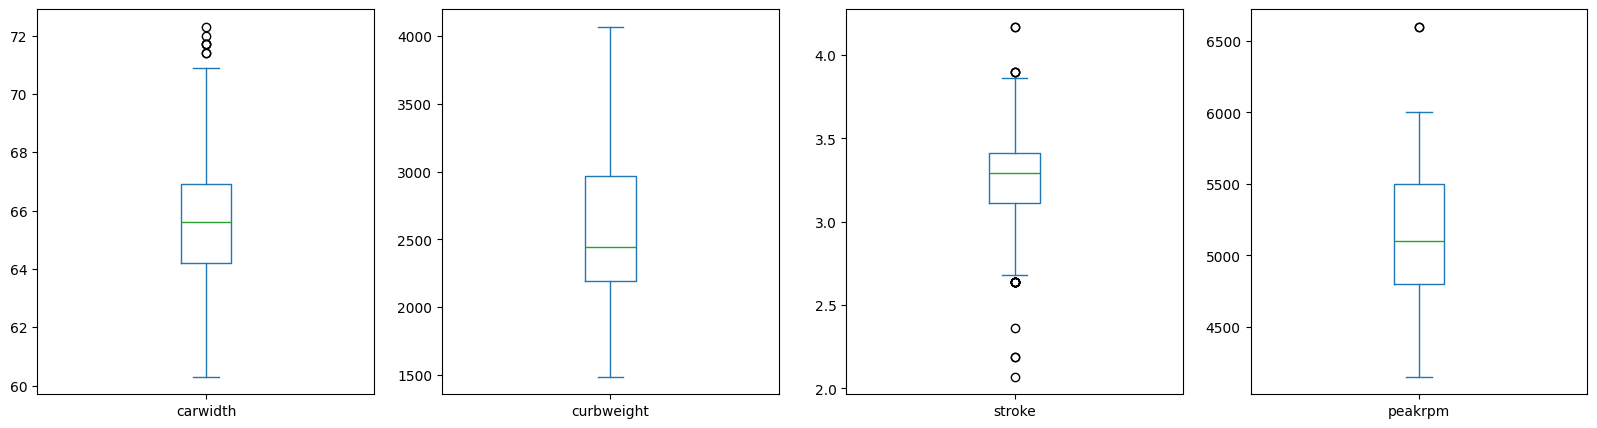

In [28]:
num_cols = ["carwidth", "curbweight", "stroke", "peakrpm"]

cars[num_cols].plot(kind="box", subplots=True, layout=(1,4), figsize=(20,5), sharey=False)
plt.show()

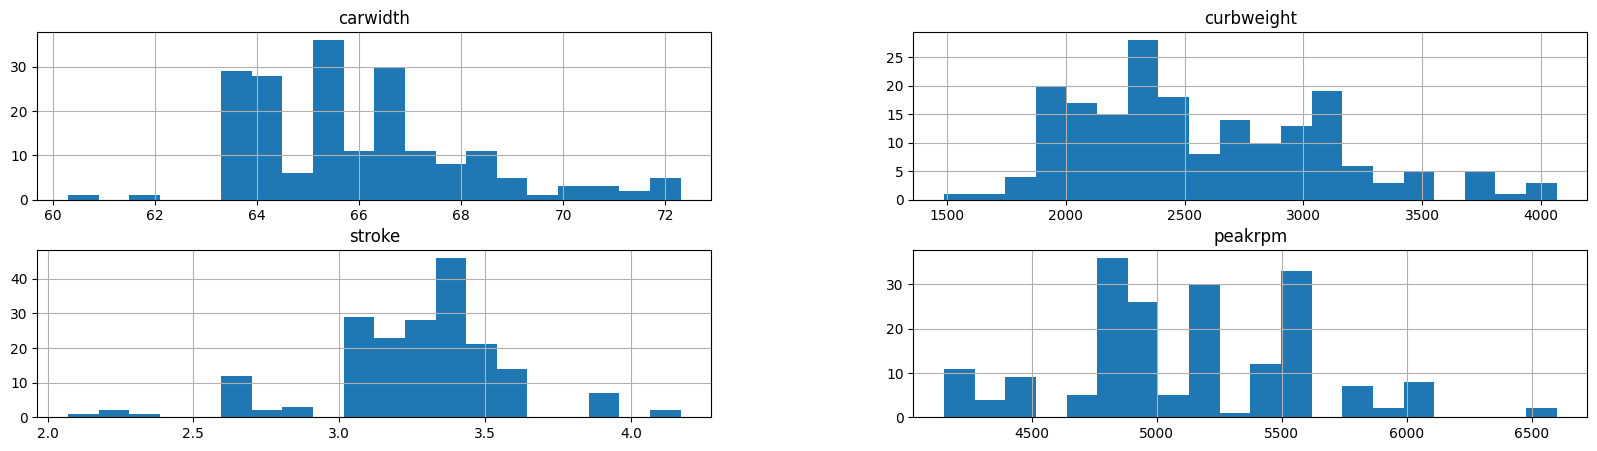

In [29]:
cars[num_cols].hist(bins=20, figsize=(20,5))
plt.show()

❓ **Soru (Sayısal sütunlara odaklanın)** ❓

Araba veri kümesinin sayısal sütunlarını `cars_num` içinde saklayın.

In [30]:
###########################
# Manuel çözüm            # - pek akıllıca değil
###########################

# num_features = ["carwidth", "curbweight", "cylindernumber", "stroke", "peakrpm"]
# cars_num = X[num_features]

# Bu, sayısal feature’ları seçmenin bir yolu...
# Ama pek akıllıca değil...

###########################
# Zarif çözüm             # - çok daha iyi
###########################

cars_num = X.select_dtypes(exclude=['object']) # yalnızca sayısal feature’ları seçiyoruz
cars_num


,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm
0,std,64.10000,2548.0,dohc,four,2.68,5000.0
2,std,65.50000,2823.0,ohcv,six,3.47,5000.0
3,std,65.88794,2337.0,ohc,four,3.40,5500.0
4,std,66.40000,2824.0,ohc,five,3.40,5500.0
5,std,66.30000,2507.0,ohc,five,3.40,5500.0
...,...,...,...,...,...,...,...
200,std,68.90000,2952.0,ohc,four,3.15,5400.0
201,turbo,68.80000,3049.0,ohc,four,3.15,5300.0
202,std,68.90000,3012.0,ohcv,six,2.87,5500.0
203,turbo,68.90000,3217.0,ohc,six,3.40,4800.0


❓ **Soru (Sağlam Ölçeklendirici)** ❓

👨🏻‍🏫 Tüm sayısal özellikleri sağlam bir şekilde ölçeklendirmek, hızlı ve verimli bir ölçeklendirme yöntemidir.

In [33]:
robust_scaler = RobustScaler().set_output(transform='pandas')
cars_num = X.select_dtypes(exclude=['object', 'category'])
cars_num_scaled = robust_scaler.fit_transform(cars_num)

categorical_features = ["aspiration", "enginetype"]
cars_categorical = X[categorical_features]

cars_categorical = X.select_dtypes(include=['object'])

## (1.5) Kategorik özelliklerin kodlanması (Encoding categorical features)

❓ **Soru (Kategorik sütunlara odaklanın)** ❓

Arabalar veri kümesinin kategorik sütunlarını `cars_categorical` içinde saklayın.

In [34]:
# Manuel çözüm --> pek akıllıca değil

# categorical_features = ["aspiration", "enginetype"]
# cars_categorical = X[categorical_features]

# Zarif çözüm --> çok daha iyi
cars_categorical = X.select_dtypes(include=['object']) # yalnızca kategorik feature’ları seçiyoruz
cars_categorical

""
0
2
3
4
5
...
200
201
202
203


❓ **Soru: Kategorik özellikleri kodlarsak, beklenen sütun sayısı kaçtır?** ❓

❓ **Soru (OneHotEncoder): Kategorik feature’ları encode edin** ❓

<details>
    <summary><i>İpuçları</i></summary>
    
- Bir kategorik feature binary ise bir sütunu drop edin
- Tam matrisler kullanın (Sklearn estimator’ları sparse matrix’leri anlayamaz)
- Sonuçları `encoded_features` adlı bir Pandas DataFrame içine kaydedin
    - 💡 OHE bir DataFrame’e fit edildikten sonra, yeni sütun adlarına _`get_features_names_out()`_ ile erişebilirsiniz
    
</details>

In [36]:
cars_categorical = X.select_dtypes(include=['object', 'category'])
cars_categorical.nunique()

aspiration        2
enginetype        7
cylindernumber    7
dtype: int64

In [37]:
ohe = OneHotEncoder(drop='if_binary', sparse_output=False)
encoded = ohe.fit_transform(cars_categorical)

encoded_features = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out()
)

encoded_features

,aspiration_turbo,enginetype_dohc,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,cylindernumber_eight,cylindernumber_five,cylindernumber_four,cylindernumber_six,cylindernumber_three,cylindernumber_twelve,cylindernumber_two
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
187,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
188,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
189,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## (1.6) Önceden işlenmiş tüm özellikleri birleştirme $X_{preprocessed}$ (Concatenating all the preprocessed features together )

❓ **Soru (önceden işlenmiş tüm özellikleri bir araya getirerek)** ❓

`cars_num_scaled` ve `encoded_features` öğelerini `X_preprocessed` öğesinde birleştirin.

In [39]:
X_preprocessed = pd.concat([cars_num_scaled, encoded_features], axis=1)
X_preprocessed 

,carwidth,curbweight,stroke,peakrpm,aspiration_turbo,enginetype_dohc,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,cylindernumber_eight,cylindernumber_five,cylindernumber_four,cylindernumber_six,cylindernumber_three,cylindernumber_twelve,cylindernumber_two
0,-0.555556,0.135659,-2.033333,-0.142857,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.037037,0.490956,0.600000,-0.142857,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.106644,-0.136951,0.366667,0.571429,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.296296,0.492248,0.366667,0.571429,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,0.259259,0.082687,0.366667,0.571429,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
123,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
127,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
159,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## (1.7) Hedefin kodlanması (Encoding the target )

❓ **Soru (Kategorik target’ın encode edilmesi)** ❓

Target değişkenini 📚[***LabelEncoder***](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) kullanarak encode edin.

In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(y_encoded)        
print(le.classes_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1
 1 1 0 0 1 1 1 1 0 0 0 0 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0
 1 0 1 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1]
['cheap' 'expensive']


# (2) 🏋🏻‍♂️ Modelleme (Modeling (Logistic Regression))

🎯 Amacımız, bazı özelliklere dayanarak bir arabanın pahalı mı yoksa ucuz mu olacağını tahmin etmektir.

## (2.0) Cross-Validation

👩‍🏫 Machine Learning’de, farklı modelleri karşılaştırmak istediğinizde, Cross Validation her bir alt modelin performansını kabaca ve sağlam bir şekilde değerlendirmek için kullanılan güçlü bir yöntemdir.

 **Soru (Çapraz Doğrulama)(CrossValidation)** ❓

Bu veri kümesi için LogisticRegression'ın potansiyel performansı nedir?

In [47]:
print(X_preprocessed.shape)
print(y.shape)
print(cars.shape)

(205, 19)
(191,)
(191, 8)


In [48]:
print(cars_num_scaled.shape)
print(encoded_features.shape)

(191, 4)
(191, 15)


In [49]:
X_preprocessed = pd.concat([cars_num_scaled, encoded_features], axis=1)
print(X_preprocessed.shape)

(205, 19)


In [50]:
cars_num_scaled = cars_num_scaled.reset_index(drop=True)
encoded_features = encoded_features.reset_index(drop=True)

X_preprocessed = pd.concat([cars_num_scaled, encoded_features], axis=1)
print(X_preprocessed.shape)

(191, 19)


In [51]:
y_encoded = le.fit_transform(y.reset_index(drop=True))

scores = cross_val_score(model, X_preprocessed, y_encoded, cv=5)
print("Her fold skoru:", scores)
print("Ortalama skor:", scores.mean().round(2))

Her fold skoru: [0.97435897 0.89473684 0.92105263 0.94736842 0.84210526]
Ortalama skor: 0.92


- 🚀 Bu doğruluk umut verici, hadi daha da ileri gidelim!
- 🗣 İyi bir Regression / Classification modelinin ne olduğunu `Performance Metrics` ünitesinde tartışacağız.

## (2.1) Holdout Method

❓ **Soru (Holdout): Dataset’inizi %70 / %30 oranında train / test olarak ayırın** ❓

<details>
    <summary><i>İpucu</i></summary>

- Binary bir target için aslında `LabelEncoder` kullanmanız gerekmez.
    - Sklearn, binary bir target’ı algılayacak kadar akıllıdır.
    
</details>

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed, y_encoded, test_size=0.3, random_state=42
)

## (2.2) Training and evaluating

❓ **Soru: Lojistik regresyon modelini Train/Evaluate** 

In [53]:
# Logistic Regression modelini oluşturma
logreg = LogisticRegression(max_iter=100)

# Modeli eğitme
logreg.fit(X_train, y_train)

# Modeli değerlendirme
logreg.score(X_test, y_test)

0.9310344827586207

## (2.3) Predicting

❓ **Soru (Yeni bir “nokta”yı tahmin etme)** ❓

ML algoritmanız (az önce eğittiğiniz Logistic Regression), aşağıdaki özelliklere sahip bir arabanın pahalı olacağını düşünüyor mu?

In [55]:
new_car = pd.DataFrame(columns=X.columns)
new_car.loc[0] = ['std', 65.88793969849246, 1874.0, 'ohc', 'four', 3.11, 5400.0]
new_car

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm
0,std,65.88794,1874.0,ohc,four,3.11,5400.0


> 👨🏻‍🏫 **Bir tahmin yapabilmek için, bu yeni aracın training set üzerinde uygulanan dönüşümlerin aynısından geçmesi gerekir!**

🌠 Bu recap’in büyük resmine [buradan](https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/prepare_dataset_fit_transform.png) göz atın!

In [ ]:
# 0 - Anormal verilerin düzeltilmesi

pass  # SENİN KODUN BURAYA

In [56]:
# 1 - Sayısal özelliklerin ölçeklendirilmesi

new_car_num = new_car.select_dtypes(exclude=['object', 'category'])
new_car_num_scaled = robust_scaler.transform(new_car_num)

In [57]:
# 2 - Kategorik özelliklerin kodlanması

new_car_cat = new_car.select_dtypes(include=['object', 'category'])
new_car_encoded = ohe.transform(new_car_cat)

/tmp/ipykernel_1326/271760515.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  new_car_cat = new_car.select_dtypes(include=['object', 'category'])


In [58]:
# 3 - Sayısal özellikleri ve kategorik özellikleri bir araya getirme

new_car_preprocessed = pd.concat([
    pd.DataFrame(new_car_num_scaled),
    pd.DataFrame(new_car_encoded)
], axis=1)

In [61]:
new_car_preprocessed.columns = new_car_preprocessed.columns.astype(str)

In [63]:
new_car_num_scaled_df = pd.DataFrame(
    new_car_num_scaled, 
    columns=cars_num_scaled.columns
)

new_car_encoded_df = pd.DataFrame(
    new_car_encoded, 
    columns=ohe.get_feature_names_out()
)

new_car_preprocessed = pd.concat([new_car_num_scaled_df, new_car_encoded_df], axis=1)

print(new_car_preprocessed.columns)  # kontrol et

Index(['carwidth', 'curbweight', 'stroke', 'peakrpm', 'aspiration_turbo',
       'enginetype_dohc', 'enginetype_dohcv', 'enginetype_l', 'enginetype_ohc',
       'enginetype_ohcf', 'enginetype_ohcv', 'enginetype_rotor',
       'cylindernumber_eight', 'cylindernumber_five', 'cylindernumber_four',
       'cylindernumber_six', 'cylindernumber_three', 'cylindernumber_twelve',
       'cylindernumber_two'],
      dtype='str')


In [64]:
# 4 - Tahmin
prediction = logreg.predict(new_car_preprocessed)
print(le.inverse_transform(prediction))



['cheap']


# (3) 🧑🏿‍🏫 Veri Sızıntısı Hakkında Uyarı (Warning about Data Leakage)

<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/cross_validation_data_leakage.png"  width=600>

🏁 Tebrikler! Artık veri seti hazırlama konusunda uzmansınız!
